In [ ]:
%pip install -q catboost scikit-learn joblib

In [1]:
import gc
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)

print("Environment ready!")
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

Environment ready!
Pandas: 3.0.5
NumPy: 2.5.2


In [2]:
PROJECT_ROOT = Path("..").resolve()

RAW_DIR = PROJECT_ROOT / "data" / "raw"
MODEL_DIR = PROJECT_ROOT / "models"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

TRANSACTION_PATH = RAW_DIR / "train_transaction.csv"
IDENTITY_PATH = RAW_DIR / "train_identity.csv"

print("Project root:")
print(PROJECT_ROOT)

print("\nTransaction file:")
print(TRANSACTION_PATH)

print("\nIdentity file:")
print(IDENTITY_PATH)

print("\nTransaction exists:", TRANSACTION_PATH.exists())
print("Identity exists:", IDENTITY_PATH.exists())

Project root:
D:\PayGuard-AI

Transaction file:
D:\PayGuard-AI\data\raw\train_transaction.csv

Identity file:
D:\PayGuard-AI\data\raw\train_identity.csv

Transaction exists: True
Identity exists: True


In [3]:
TRANSACTION_CATEGORICAL = (
    ["ProductCD"]
    + [f"card{i}" for i in range(1, 7)]
    + ["addr1", "addr2"]
    + ["P_emaildomain", "R_emaildomain"]
    + [f"M{i}" for i in range(1, 10)]
)

TRANSACTION_NUMERIC = (
    [
        "TransactionDT",
        "TransactionAmt",
        "dist1",
        "dist2"
    ]
    + [f"C{i}" for i in range(1, 15)]
    + [f"D{i}" for i in range(1, 16)]
)

IDENTITY_CATEGORICAL = (
    ["DeviceType", "DeviceInfo"]
    + [f"id_{i}" for i in range(12, 39)]
)

TRANSACTION_COLUMNS = (
    ["TransactionID", "isFraud"]
    + TRANSACTION_CATEGORICAL
    + TRANSACTION_NUMERIC
)

IDENTITY_COLUMNS = (
    ["TransactionID"]
    + IDENTITY_CATEGORICAL
)

print(
    "Requested transaction columns:",
    len(TRANSACTION_COLUMNS)
)

print(
    "Requested identity columns:",
    len(IDENTITY_COLUMNS)
)

Requested transaction columns: 55
Requested identity columns: 30


In [4]:
transaction_header = pd.read_csv(
    TRANSACTION_PATH,
    nrows=0
)

identity_header = pd.read_csv(
    IDENTITY_PATH,
    nrows=0
)

available_transaction = set(
    transaction_header.columns
)

available_identity = set(
    identity_header.columns
)

transaction_usecols = [
    col
    for col in TRANSACTION_COLUMNS
    if col in available_transaction
]

identity_usecols = [
    col
    for col in IDENTITY_COLUMNS
    if col in available_identity
]

print(
    "Transaction columns found:",
    len(transaction_usecols)
)

print(
    "Identity columns found:",
    len(identity_usecols)
)

missing_transaction = [
    col
    for col in TRANSACTION_COLUMNS
    if col not in available_transaction
]

missing_identity = [
    col
    for col in IDENTITY_COLUMNS
    if col not in available_identity
]

print("\nMissing transaction columns:")
print(missing_transaction)

print("\nMissing identity columns:")
print(missing_identity)

Transaction columns found: 55
Identity columns found: 30

Missing transaction columns:
[]

Missing identity columns:
[]


In [5]:
print("Loading train_transaction.csv...")
print("This can take some time.")

train_transaction = pd.read_csv(
    TRANSACTION_PATH,
    usecols=transaction_usecols,
    low_memory=False
)

print("\nTransaction dataset loaded!")

print(
    "Shape:",
    train_transaction.shape
)

Loading train_transaction.csv...
This can take some time.

Transaction dataset loaded!
Shape: (590540, 55)


In [6]:
print("Loading train_identity.csv...")

train_identity = pd.read_csv(
    IDENTITY_PATH,
    usecols=identity_usecols,
    low_memory=False
)

print("\nIdentity dataset loaded!")

print(
    "Shape:",
    train_identity.shape
)

Loading train_identity.csv...

Identity dataset loaded!
Shape: (144233, 30)


In [7]:
print("Fraud distribution:")
print(
    train_transaction["isFraud"]
    .value_counts()
)

print("\nFraud percentage:")

fraud_percentage = (
    train_transaction["isFraud"]
    .value_counts(normalize=True)
    * 100
)

print(
    fraud_percentage.round(4)
)

Fraud distribution:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud percentage:
isFraud
0    96.501
1     3.499
Name: proportion, dtype: float64


In [8]:
print("Merging datasets...")

df = train_transaction.merge(
    train_identity,
    on="TransactionID",
    how="left"
)

print("\nMerged dataset shape:")
print(df.shape)

Merging datasets...

Merged dataset shape:
(590540, 84)


In [9]:
del train_transaction
del train_identity
del transaction_header
del identity_header

gc.collect()

print("Unused memory released.")

Unused memory released.


In [10]:
df = df.sort_values(
    "TransactionDT",
    kind="mergesort"
).reset_index(drop=True)

print("Dataset sorted chronologically.")

print(
    "First TransactionDT:",
    df["TransactionDT"].min()
)

print(
    "Last TransactionDT:",
    df["TransactionDT"].max()
)

Dataset sorted chronologically.
First TransactionDT: 86400
Last TransactionDT: 15811131


In [11]:
SECONDS_PER_DAY = 86400

df["transaction_day"] = (
    df["TransactionDT"] // SECONDS_PER_DAY
)

df["transaction_hour"] = (
    (df["TransactionDT"] % SECONDS_PER_DAY)
    // 3600
)

df["transaction_dow"] = (
    df["transaction_day"] % 7
)

print(
    df[
        [
            "TransactionDT",
            "transaction_day",
            "transaction_hour",
            "transaction_dow"
        ]
    ].head()
)

   TransactionDT  transaction_day  transaction_hour  transaction_dow
0          86400                1                 0                1
1          86401                1                 0                1
2          86469                1                 0                1
3          86499                1                 0                1
4          86506                1                 0                1


In [12]:
df["amount_log"] = np.log1p(
    df["TransactionAmt"]
)

df["amount_cents"] = (
    np.round(
        df["TransactionAmt"] * 100
    )
    .astype("int64")
    % 100
)

df["amount_is_round"] = (
    df["amount_cents"] == 0
).astype("int8")

print(
    df[
        [
            "TransactionAmt",
            "amount_log",
            "amount_cents",
            "amount_is_round"
        ]
    ].head()
)

   TransactionAmt  amount_log  amount_cents  amount_is_round
0            68.5    4.241327            50                0
1            29.0    3.401197             0                1
2            59.0    4.094345             0                1
3            50.0    3.931826             0                1
4            50.0    3.931826             0                1


In [13]:
df["identity_missing"] = (
    df["DeviceType"].isna()
).astype("int8")

print(
    df["identity_missing"]
    .value_counts()
)

identity_missing
1    449730
0    140810
Name: count, dtype: int64


In [14]:
df["email_match"] = (
    df["P_emaildomain"]
    .fillna("__MISSING__")
    ==
    df["R_emaildomain"]
    .fillna("__MISSING__")
).astype("int8")

print(
    df[
        [
            "P_emaildomain",
            "R_emaildomain",
            "email_match"
        ]
    ].head()
)

  P_emaildomain R_emaildomain  email_match
0           NaN           NaN            1
1     gmail.com           NaN            0
2   outlook.com           NaN            0
3     yahoo.com           NaN            0
4     gmail.com           NaN            0


In [15]:
def safe_str(series):
    return (
        series
        .fillna("__MISSING__")
        .astype(str)
    )

print("Helper function created.")

Helper function created.


In [16]:
df["card_key"] = (
    safe_str(df["card1"]) + "_" +
    safe_str(df["card2"]) + "_" +
    safe_str(df["card3"]) + "_" +
    safe_str(df["card4"]) + "_" +
    safe_str(df["card5"]) + "_" +
    safe_str(df["card6"])
)

print(
    df["card_key"].head()
)

0    13926___MISSING___150.0_discover_142.0_credit
1         2755_404.0_150.0_mastercard_102.0_credit
2                4663_490.0_150.0_visa_166.0_debit
3         18132_567.0_150.0_mastercard_117.0_debit
4         4497_514.0_150.0_mastercard_102.0_credit
Name: card_key, dtype: str


In [17]:
df["card_addr_key"] = (
    safe_str(df["card1"])
    + "_"
    + safe_str(df["addr1"])
)

print(
    df["card_addr_key"].head()
)

0    13926_315.0
1     2755_325.0
2     4663_330.0
3    18132_476.0
4     4497_420.0
Name: card_addr_key, dtype: str


In [18]:
df["card_device_key"] = (
    safe_str(df["card1"])
    + "_"
    + safe_str(df["DeviceInfo"])
)

print(
    df["card_device_key"].head()
)

0                     13926___MISSING__
1                      2755___MISSING__
2                      4663___MISSING__
3                     18132___MISSING__
4    4497_SAMSUNG SM-G892A Build/NRD90M
Name: card_device_key, dtype: str


In [19]:
df["user_key"] = (
    safe_str(df["card1"])
    + "_"
    + safe_str(df["card2"])
    + "_"
    + safe_str(df["addr1"])
    + "_"
    + safe_str(df["P_emaildomain"])
)

print(
    df["user_key"].head()
)

0    13926___MISSING___315.0___MISSING__
1             2755_404.0_325.0_gmail.com
2           4663_490.0_330.0_outlook.com
3            18132_567.0_476.0_yahoo.com
4             4497_514.0_420.0_gmail.com
Name: user_key, dtype: str


In [20]:
split_index = int(
    len(df) * 0.80
)

train_df = df.iloc[
    :split_index
].copy()

valid_df = df.iloc[
    split_index:
].copy()

print("Training rows:", len(train_df))
print("Validation rows:", len(valid_df))

print("\nTraining period:")
print(
    train_df["TransactionDT"].min(),
    "→",
    train_df["TransactionDT"].max()
)

print("\nValidation period:")
print(
    valid_df["TransactionDT"].min(),
    "→",
    valid_df["TransactionDT"].max()
)

Training rows: 472432
Validation rows: 118108

Training period:
86400 → 12192842

Validation period:
12192900 → 15811131


In [21]:
TARGET = "isFraud"

print("========== TRAIN ==========")

print(
    train_df[TARGET]
    .value_counts()
)

print(
    "\nFraud rate:",
    round(
        train_df[TARGET].mean() * 100,
        4
    ),
    "%"
)

print("\n========== VALIDATION ==========")

print(
    valid_df[TARGET]
    .value_counts()
)

print(
    "\nFraud rate:",
    round(
        valid_df[TARGET].mean() * 100,
        4
    ),
    "%"
)

========== TRAIN ==========
isFraud
0    455833
1     16599
Name: count, dtype: int64

Fraud rate: 3.5135 %

========== VALIDATION ==========
isFraud
0    114044
1      4064
Name: count, dtype: int64

Fraud rate: 3.4409 %


In [22]:
FREQUENCY_COLUMNS = [
    "card1",
    "card2",
    "card_addr_key",
    "card_device_key",
    "user_key",
    "P_emaildomain",
    "DeviceInfo"
]

for col in FREQUENCY_COLUMNS:

    if col not in train_df.columns:
        continue

    frequency_map = (
        train_df[col]
        .value_counts(
            dropna=False
        )
    )

    train_df[f"{col}_freq"] = (
        train_df[col]
        .map(frequency_map)
        .fillna(0)
        .astype("float32")
    )

    valid_df[f"{col}_freq"] = (
        valid_df[col]
        .map(frequency_map)
        .fillna(0)
        .astype("float32")
    )

print("Frequency features created.")

print(
    [
        f"{col}_freq"
        for col in FREQUENCY_COLUMNS
        if col in train_df.columns
    ]
)

Frequency features created.
['card1_freq', 'card2_freq', 'card_addr_key_freq', 'card_device_key_freq', 'user_key_freq', 'P_emaildomain_freq', 'DeviceInfo_freq']


In [23]:
amount_stats = (
    train_df
    .groupby("card1")["TransactionAmt"]
    .agg(
        card_amount_mean="mean",
        card_amount_std="std"
    )
)

train_df = train_df.join(
    amount_stats,
    on="card1"
)

valid_df = valid_df.join(
    amount_stats,
    on="card1"
)

train_df["amount_vs_card_mean"] = (
    train_df["TransactionAmt"]
    /
    train_df[
        "card_amount_mean"
    ].replace(
        0,
        np.nan
    )
)

valid_df["amount_vs_card_mean"] = (
    valid_df["TransactionAmt"]
    /
    valid_df[
        "card_amount_mean"
    ].replace(
        0,
        np.nan
    )
)

print(
    train_df[
        [
            "TransactionAmt",
            "card_amount_mean",
            "card_amount_std",
            "amount_vs_card_mean"
        ]
    ].head()
)

   TransactionAmt  card_amount_mean  card_amount_std  amount_vs_card_mean
0            68.5        353.869762       375.419688             0.193574
1            29.0        235.623018       481.888744             0.123078
2            59.0         93.583296        98.886510             0.630454
3            50.0        123.557544       186.493777             0.404670
4            50.0         94.123077        54.254203             0.531219


In [24]:
MODEL_CATEGORICAL = (
    TRANSACTION_CATEGORICAL
    + IDENTITY_CATEGORICAL
    + [
        "card_key",
        "card_addr_key",
        "card_device_key",
        "user_key"
    ]
)

MODEL_CATEGORICAL = list(
    dict.fromkeys(
        MODEL_CATEGORICAL
    )
)

CAT_FEATURES = [
    col
    for col in MODEL_CATEGORICAL
    if col in train_df.columns
]

print(
    "Number of categorical features:",
    len(CAT_FEATURES)
)

print("\nCategorical features:")
print(CAT_FEATURES)

Number of categorical features: 53

Categorical features:
['ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'DeviceType', 'DeviceInfo', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'card_key', 'card_addr_key', 'card_device_key', 'user_key']


In [25]:
DROP_COLUMNS = [
    "isFraud",
    "TransactionID",
    "TransactionDT"
]

feature_columns = [
    col
    for col in train_df.columns
    if col not in DROP_COLUMNS
]

X_train = train_df[
    feature_columns
].copy()

X_valid = valid_df[
    feature_columns
].copy()

y_train = train_df[
    TARGET
].astype("int8")

y_valid = valid_df[
    TARGET
].astype("int8")

print(
    "Number of model features:",
    len(feature_columns)
)

print(
    "X_train shape:",
    X_train.shape
)

print(
    "X_valid shape:",
    X_valid.shape
)

Number of model features: 103
X_train shape: (472432, 103)
X_valid shape: (118108, 103)


In [26]:
for col in CAT_FEATURES:

    X_train[col] = (
        X_train[col]
        .fillna("__MISSING__")
        .astype(str)
    )

    X_valid[col] = (
        X_valid[col]
        .fillna("__MISSING__")
        .astype(str)
    )

print(
    "Categorical preprocessing complete."
)

Categorical preprocessing complete.


In [27]:
for data_part in [
    X_train,
    X_valid
]:

    numeric_columns = (
        data_part
        .select_dtypes(
            include=[
                "int64",
                "float64"
            ]
        )
        .columns
    )

    for col in numeric_columns:

        data_part[col] = (
            data_part[col]
            .astype("float32")
        )

print(
    "Numerical memory optimization complete."
)

Numerical memory optimization complete.


In [28]:
print("===================================")
print("FINAL TRAINING DATA CHECK")
print("===================================")

print(
    "Training:",
    X_train.shape
)

print(
    "Validation:",
    X_valid.shape
)

print(
    "Categorical features:",
    len(CAT_FEATURES)
)

print(
    "Fraud training rate:",
    round(
        y_train.mean() * 100,
        4
    ),
    "%"
)

print(
    "Fraud validation rate:",
    round(
        y_valid.mean() * 100,
        4
    ),
    "%"
)

print("\nData ready for CatBoost.")

FINAL TRAINING DATA CHECK
Training: (472432, 103)
Validation: (118108, 103)
Categorical features: 53
Fraud training rate: 3.5135 %
Fraud validation rate: 3.4409 %

Data ready for CatBoost.


In [29]:
model = CatBoostClassifier(
    iterations=1200,
    learning_rate=0.05,
    depth=8,

    loss_function="Logloss",
    eval_metric="AUC",

    auto_class_weights="Balanced",

    random_seed=42,

    l2_leaf_reg=5,
    random_strength=1,

    border_count=128,

    verbose=100,

    allow_writing_files=False,

    thread_count=-1
)

print(
    "CatBoost model created."
)

CatBoost model created.


In [30]:
print("===================================")
print("PAYGUARD AI TRAINING STARTED")
print("===================================")

model.fit(
    X_train,
    y_train,

    cat_features=CAT_FEATURES,

    eval_set=(
        X_valid,
        y_valid
    ),

    use_best_model=True,

    early_stopping_rounds=100
)

print("\n===================================")
print("TRAINING COMPLETE")
print("===================================")

print(
    "Best iteration:",
    model.get_best_iteration()
)

PAYGUARD AI TRAINING STARTED
0:	test: 0.8334963	best: 0.8334963 (0)	total: 2.7s	remaining: 53m 57s
100:	test: 0.9130106	best: 0.9130106 (100)	total: 6m 35s	remaining: 1h 11m 38s
200:	test: 0.9196413	best: 0.9198039 (194)	total: 16m 26s	remaining: 1h 21m 40s
300:	test: 0.9248055	best: 0.9248055 (300)	total: 29m 55s	remaining: 1h 29m 21s
400:	test: 0.9274059	best: 0.9276032 (399)	total: 40m 40s	remaining: 1h 21m 2s
500:	test: 0.9293840	best: 0.9293840 (500)	total: 50m 18s	remaining: 1h 10m 11s
600:	test: 0.9295291	best: 0.9298358 (569)	total: 1h 1m 51s	remaining: 1h 1m 39s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9298357702
bestIteration = 569

Shrink model to first 570 iterations.

TRAINING COMPLETE
Best iteration: 569


In [31]:
valid_probability = (
    model
    .predict_proba(
        X_valid
    )[:, 1]
)

print(
    "Predictions generated."
)

print(
    "Minimum probability:",
    valid_probability.min()
)

print(
    "Maximum probability:",
    valid_probability.max()
)

Predictions generated.
Minimum probability: 7.032535589315665e-06
Maximum probability: 0.9999129108750164


In [33]:
# ============================================================
# THRESHOLD TUNING + FINAL HOLDOUT EVALUATION
# ============================================================
# The original notebook chooses the threshold on the full validation set.
# For a more honest operating-point evaluation, split the existing
# chronological validation set into:
#   1) calibration set -> choose threshold
#   2) final holdout   -> report unbiased operating metrics
#
# This does not retrain the model. It only prevents the final threshold
# report from being evaluated on the same rows used to choose the threshold.

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    precision_recall_curve,
)

VALID_CALIBRATION_FRACTION = 0.50

calibration_size = int(len(y_valid) * VALID_CALIBRATION_FRACTION)

calibration_y = y_valid.iloc[:calibration_size].reset_index(drop=True)
holdout_y = y_valid.iloc[calibration_size:].reset_index(drop=True)

calibration_probability = valid_probability[:calibration_size]
holdout_probability = valid_probability[calibration_size:]

print("==============================================")
print("THRESHOLD CALIBRATION / FINAL HOLDOUT")
print("==============================================")
print("Calibration rows:", len(calibration_y))
print("Holdout rows    :", len(holdout_y))
print("Calibration fraud rate:", round(calibration_y.mean() * 100, 4), "%")
print("Holdout fraud rate    :", round(holdout_y.mean() * 100, 4), "%")

# ------------------------------------------------------------
# Choose threshold ONLY on calibration rows
# ------------------------------------------------------------
cal_precision, cal_recall, cal_thresholds = precision_recall_curve(
    calibration_y,
    calibration_probability,
)

cal_f1 = (
    2 * cal_precision[:-1] * cal_recall[:-1]
    / (cal_precision[:-1] + cal_recall[:-1] + 1e-12)
)

cal_best_index = int(np.argmax(cal_f1))
calibration_best_threshold = float(cal_thresholds[cal_best_index])

print("Calibration-selected threshold:", round(calibration_best_threshold, 6))
print("Calibration F1:", round(float(cal_f1[cal_best_index]), 6))

# ------------------------------------------------------------
# Evaluate practical candidate thresholds on the final holdout
# ------------------------------------------------------------
candidate_thresholds = sorted(set([
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    round(calibration_best_threshold, 6),
    0.864575,
]))

rows = []

for threshold_value in candidate_thresholds:
    pred = (holdout_probability >= threshold_value).astype("int8")

    precision_value_ = precision_score(
        holdout_y, pred, zero_division=0
    )
    recall_value_ = recall_score(
        holdout_y, pred, zero_division=0
    )
    f1_value_ = f1_score(
        holdout_y, pred, zero_division=0
    )

    cm_ = confusion_matrix(
        holdout_y, pred
    )

    tn, fp, fn, tp = cm_.ravel()

    rows.append({
        "threshold": threshold_value,
        "precision": precision_value_,
        "recall": recall_value_,
        "f1": f1_value_,
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
        "true_negatives": int(tn),
        "block_rate_pct": float(pred.mean() * 100),
    })

threshold_comparison = pd.DataFrame(rows)

print("\n==============================================")
print("HOLDOUT THRESHOLD COMPARISON")
print("==============================================")
display(threshold_comparison.round(6))

# ------------------------------------------------------------
# Recommended production candidate
# ------------------------------------------------------------
# Default recommendation: use the calibration-selected threshold,
# but only after reviewing the business trade-off in the table above.
RECOMMENDED_THRESHOLD = calibration_best_threshold

holdout_prediction = (
    holdout_probability >= RECOMMENDED_THRESHOLD
).astype("int8")

holdout_precision = precision_score(
    holdout_y,
    holdout_prediction,
    zero_division=0,
)

holdout_recall = recall_score(
    holdout_y,
    holdout_prediction,
    zero_division=0,
)

holdout_f1 = f1_score(
    holdout_y,
    holdout_prediction,
    zero_division=0,
)

holdout_cm = confusion_matrix(
    holdout_y,
    holdout_prediction,
)

print("\n==============================================")
print("RECOMMENDED THRESHOLD HOLDOUT RESULTS")
print("==============================================")
print("Recommended threshold:", round(RECOMMENDED_THRESHOLD, 6))
print("Holdout Precision   :", round(holdout_precision, 6))
print("Holdout Recall      :", round(holdout_recall, 6))
print("Holdout F1          :", round(holdout_f1, 6))
print("Holdout Confusion Matrix:")
print(holdout_cm)

# ------------------------------------------------------------
# IMPORTANT: override the notebook's original threshold/metrics
# variables so the subsequent save/export cells persist the new
# operating threshold and holdout metrics.
# ------------------------------------------------------------
best_threshold = RECOMMENDED_THRESHOLD
valid_prediction = (
    valid_probability >= best_threshold
).astype("int8")

precision_value = precision_score(
    y_valid,
    valid_prediction,
    zero_division=0,
)

recall_value = recall_score(
    y_valid,
    valid_prediction,
    zero_division=0,
)

f1_value = f1_score(
    y_valid,
    valid_prediction,
    zero_division=0,
)

print("Export threshold set to:", round(best_threshold, 6))
print("NOTE: ROC-AUC/PR-AUC remain full validation ranking metrics.")
print("Use the HOLDOUT Precision/Recall/F1 above for threshold decisions.")


THRESHOLD CALIBRATION / FINAL HOLDOUT
Calibration rows: 59054
Holdout rows    : 59054
Calibration fraud rate: 3.1344 %
Holdout fraud rate    : 3.7474 %
Calibration-selected threshold: 0.886994
Calibration F1: 0.613737

HOLDOUT THRESHOLD COMPARISON


,threshold,precision,recall,f1,false_positives,false_negatives,true_positives,true_negatives,block_rate_pct
0,0.300000,0.194919,0.825124,0.315344,7542,387,1826,49299,15.863447
1,0.400000,0.250547,0.776322,0.378831,5139,495,1718,51702,11.611407
2,0.500000,0.310215,0.709444,0.431674,3491,643,1570,53350,8.570122
3,0.600000,0.383825,0.658382,0.484939,2339,756,1457,54502,6.428015
4,0.700000,0.472193,0.602350,0.529388,1490,880,1333,55351,4.780371
5,0.800000,0.579759,0.543606,0.561101,872,1010,1203,55969,3.513733
6,0.864575,0.666258,0.491640,0.565783,545,1125,1088,56296,2.765266
7,0.886994,0.701493,0.467239,0.560890,440,1179,1034,56401,2.496021



RECOMMENDED THRESHOLD HOLDOUT RESULTS
Recommended threshold: 0.886994
Holdout Precision   : 0.701493
Holdout Recall      : 0.467239
Holdout F1          : 0.56089
Holdout Confusion Matrix:
[[56401   440]
 [ 1179  1034]]
Export threshold set to: 0.886994
NOTE: ROC-AUC/PR-AUC remain full validation ranking metrics.
Use the HOLDOUT Precision/Recall/F1 above for threshold decisions.


In [34]:
roc_auc = roc_auc_score(
    y_valid,
    valid_probability
)

print(
    "ROC-AUC:",
    round(
        roc_auc,
        6
    )
)

ROC-AUC: 0.929836


In [35]:
pr_auc = average_precision_score(
    y_valid,
    valid_probability
)

print(
    "PR-AUC:",
    round(
        pr_auc,
        6
    )
)

PR-AUC: 0.600044


In [36]:
precision_curve, recall_curve, thresholds = (
    precision_recall_curve(
        y_valid,
        valid_probability
    )
)

f1_scores = (
    2
    * precision_curve[:-1]
    * recall_curve[:-1]
    /
    (
        precision_curve[:-1]
        + recall_curve[:-1]
        + 1e-12
    )
)

best_index = np.argmax(
    f1_scores
)

best_threshold = float(
    thresholds[best_index]
)

print(
    "Best threshold:",
    round(
        best_threshold,
        6
    )
)

print(
    "Best F1:",
    round(
        float(
            f1_scores[best_index]
        ),
        6
    )
)

Best threshold: 0.864575
Best F1: 0.587133


In [37]:
valid_prediction = (
    valid_probability
    >= best_threshold
).astype("int8")

precision_value = precision_score(
    y_valid,
    valid_prediction,
    zero_division=0
)

recall_value = recall_score(
    y_valid,
    valid_prediction,
    zero_division=0
)

f1_value = f1_score(
    y_valid,
    valid_prediction,
    zero_division=0
)

print(
    "Precision:",
    round(
        precision_value,
        6
    )
)

print(
    "Recall:",
    round(
        recall_value,
        6
    )
)

print(
    "F1:",
    round(
        f1_value,
        6
    )
)

Precision: 0.680169
Recall: 0.516486
F1: 0.587133


In [38]:
print(
    classification_report(
        y_valid,
        valid_prediction,
        digits=4,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0     0.9829    0.9913    0.9871    114044
           1     0.6802    0.5165    0.5871      4064

    accuracy                         0.9750    118108
   macro avg     0.8315    0.7539    0.7871    118108
weighted avg     0.9725    0.9750    0.9733    118108



In [39]:
cm = confusion_matrix(
    y_valid,
    valid_prediction
)

print(
    "Confusion Matrix:"
)

print(cm)

Confusion Matrix:
[[113057    987]
 [  1965   2099]]


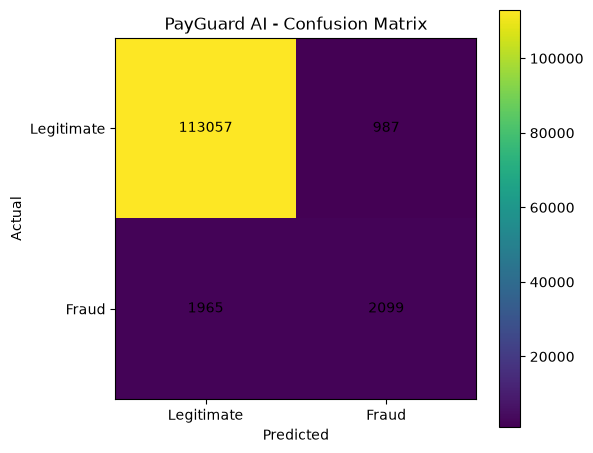

In [40]:
plt.figure(
    figsize=(6, 5)
)

plt.imshow(cm)

plt.title(
    "PayGuard AI - Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.xticks(
    [0, 1],
    [
        "Legitimate",
        "Fraud"
    ]
)

plt.yticks(
    [0, 1],
    [
        "Legitimate",
        "Fraud"
    ]
)

for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.tight_layout()

plt.show()

In [41]:
importance = pd.DataFrame({
    "feature": model.feature_names_,
    "importance": model.feature_importances_
})

importance = (
    importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    "Top 30 features:"
)

display(
    importance.head(30)
)

Top 30 features:


,feature,importance
0,user_key,5.629983
1,card_addr_key_freq,5.145152
2,card_addr_key,5.029161
3,M5,4.607208
4,transaction_day,3.630026
5,C13,3.582734
6,C1,3.440711
7,D2,3.043810
8,user_key_freq,2.950899
9,M6,2.566035


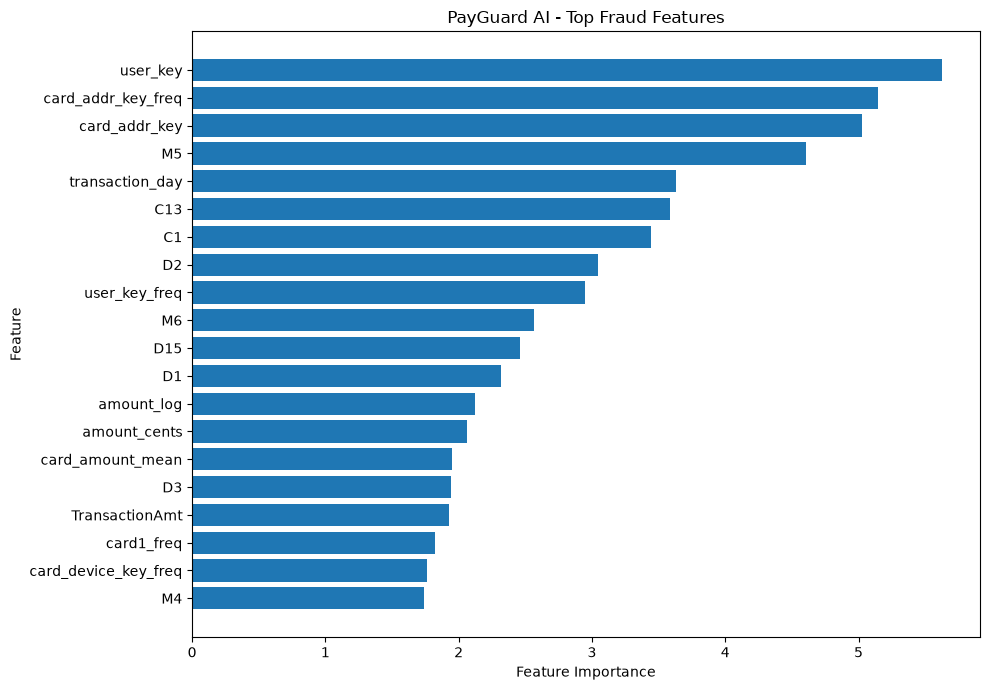

In [42]:
top_features = (
    importance
    .head(20)
    .sort_values(
        "importance"
    )
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.title(
    "PayGuard AI - Top Fraud Features"
)

plt.xlabel(
    "Feature Importance"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.show()

In [43]:
MODEL_PATH = (
    MODEL_DIR
    / "payguard_fraud_catboost.cbm"
)

model.save_model(
    str(MODEL_PATH)
)

print(
    "==================================="
)

print(
    "MODEL SAVED SUCCESSFULLY"
)

print(
    MODEL_PATH
)

print(
    "==================================="
)

MODEL SAVED SUCCESSFULLY
D:\PayGuard-AI\models\payguard_fraud_catboost.cbm


In [44]:
config = {
    "model_type": "CatBoostClassifier",

    "target": TARGET,

    "features": feature_columns,

    "categorical_features": CAT_FEATURES,

    "threshold": best_threshold,

    "roc_auc": float(
        roc_auc
    ),

    "pr_auc": float(
        pr_auc
    ),

    "precision": float(
        precision_value
    ),

    "recall": float(
        recall_value
    ),

    "f1": float(
        f1_value
    )
}

CONFIG_PATH = (
    MODEL_DIR
    / "payguard_model_config.json"
)

with open(
    CONFIG_PATH,
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )

print(
    "Configuration saved:"
)

print(
    CONFIG_PATH
)

Configuration saved:
D:\PayGuard-AI\models\payguard_model_config.json


In [45]:
validation_output = pd.DataFrame({

    "TransactionID":
        valid_df[
            "TransactionID"
        ].values,

    "actual_fraud":
        y_valid.values,

    "fraud_probability":
        valid_probability,

    "predicted_fraud":
        valid_prediction
})

print(
    validation_output.head()
)

print(
    "\nShape:",
    validation_output.shape
)

   TransactionID  actual_fraud  fraud_probability  predicted_fraud
0        3459432             1           0.507173                0
1        3459433             0           0.006369                0
2        3459434             0           0.537604                0
3        3459435             0           0.517374                0
4        3459436             0           0.115954                0

Shape: (118108, 4)


In [46]:
validation_output[
    "risk_score"
] = (
    validation_output[
        "fraud_probability"
    ]
    * 100
).round(2)


def risk_level(score):

    if score >= 80:
        return "HIGH"

    elif score >= 50:
        return "MEDIUM"

    else:
        return "LOW"


validation_output[
    "risk_level"
] = (
    validation_output[
        "risk_score"
    ]
    .apply(risk_level)
)

display(
    validation_output.head(20)
)

,TransactionID,actual_fraud,fraud_probability,predicted_fraud,risk_score,risk_level
0,3459432,1,0.507173,0,50.72,MEDIUM
1,3459433,0,0.006369,0,0.64,LOW
2,3459434,0,0.537604,0,53.76,MEDIUM
3,3459435,0,0.517374,0,51.74,MEDIUM
4,3459436,0,0.115954,0,11.60,LOW
5,3459437,0,0.124340,0,12.43,LOW
6,3459438,0,0.011541,0,1.15,LOW
7,3459439,0,0.198063,0,19.81,LOW
8,3459440,0,0.196221,0,19.62,LOW
9,3459441,0,0.090381,0,9.04,LOW


In [47]:
print(
    validation_output[
        "risk_level"
    ].value_counts()
)

risk_level
LOW       108689
MEDIUM      5552
HIGH        3867
Name: count, dtype: int64


In [48]:
VALIDATION_PATH = (
    PROCESSED_DIR
    / "fraud_validation_predictions.csv"
)

validation_output.to_csv(
    VALIDATION_PATH,
    index=False
)

print(
    "Validation predictions saved:"
)

print(
    VALIDATION_PATH
)

Validation predictions saved:
D:\PayGuard-AI\data\processed\fraud_validation_predictions.csv


In [49]:
print()
print("==============================================")
print("             PAYGUARD AI RESULTS")
print("==============================================")

print(
    f"Training rows       : {len(X_train):,}"
)

print(
    f"Validation rows     : {len(X_valid):,}"
)

print(
    f"Features            : {len(feature_columns)}"
)

print(
    f"Categorical features: {len(CAT_FEATURES)}"
)

print(
    f"ROC-AUC             : {roc_auc:.6f}"
)

print(
    f"PR-AUC              : {pr_auc:.6f}"
)

print(
    f"Precision            : {precision_value:.6f}"
)

print(
    f"Recall               : {recall_value:.6f}"
)

print(
    f"F1                   : {f1_value:.6f}"
)

print(
    f"Threshold            : {best_threshold:.6f}"
)

print()
print(
    "Model:"
)

print(
    MODEL_PATH
)

print()
print(
    "Configuration:"
)

print(
    CONFIG_PATH
)

print()
print(
    "Predictions:"
)

print(
    VALIDATION_PATH
)

print("==============================================")
print("              TRAINING COMPLETE")
print("==============================================")


             PAYGUARD AI RESULTS
Training rows       : 472,432
Validation rows     : 118,108
Features            : 103
Categorical features: 53
ROC-AUC             : 0.929836
PR-AUC              : 0.600044
Precision            : 0.680169
Recall               : 0.516486
F1                   : 0.587133
Threshold            : 0.864575

Model:
D:\PayGuard-AI\models\payguard_fraud_catboost.cbm

Configuration:
D:\PayGuard-AI\models\payguard_model_config.json

Predictions:
D:\PayGuard-AI\data\processed\fraud_validation_predictions.csv
              TRAINING COMPLETE


In [75]:
MODEL_PATH = MODEL_DIR / "payguard_fraud_catboost.cbm"

model.save_model(str(MODEL_PATH))

print("MODEL SAVED SUCCESSFULLY")
print(MODEL_PATH)

MODEL SAVED SUCCESSFULLY
D:\PayGuard-AI\models\payguard_fraud_catboost.cbm


In [51]:
config = {
    "model_type": "CatBoostClassifier",
    "target": TARGET,
    "features": feature_columns,
    "categorical_features": CAT_FEATURES,
    "threshold": best_threshold,
    "roc_auc": float(roc_auc),
    "pr_auc": float(pr_auc),
    "precision": float(precision_value),
    "recall": float(recall_value),
    "f1": float(f1_value)
}

CONFIG_PATH = MODEL_DIR / "payguard_model_config.json"

with open(CONFIG_PATH, "w") as f:
    json.dump(config, f, indent=4)

print("CONFIG SAVED")
print(CONFIG_PATH)

CONFIG SAVED
D:\PayGuard-AI\models\payguard_model_config.json


In [52]:
import joblib

ARTIFACT_PATH = MODEL_DIR / "payguard_preprocessing.joblib"

frequency_maps = {}

for col in FREQUENCY_COLUMNS:

    if col not in train_df.columns:
        continue

    frequency_maps[col] = (
        train_df[col]
        .value_counts(dropna=False)
        .to_dict()
    )


preprocessing_artifacts = {
    "frequency_maps": frequency_maps,
    "amount_stats": amount_stats,
    "feature_columns": feature_columns,
    "categorical_features": CAT_FEATURES,
    "threshold": best_threshold
}


joblib.dump(
    preprocessing_artifacts,
    ARTIFACT_PATH
)

print("Preprocessing artifacts saved!")
print(ARTIFACT_PATH)

Preprocessing artifacts saved!
D:\PayGuard-AI\models\payguard_preprocessing.joblib


In [53]:
# ============================================================
# FINAL PAYGUARD MODEL READINESS SUMMARY
# ============================================================
print()
print("============================================================")
print("PAYGUARD MODEL READINESS SUMMARY")
print("============================================================")
print(f"Features                 : {len(feature_columns)}")
print(f"Categorical features     : {len(CAT_FEATURES)}")
print(f"Full validation ROC-AUC  : {roc_auc:.6f}")
print(f"Full validation PR-AUC   : {pr_auc:.6f}")
print(f"Recommended threshold    : {best_threshold:.6f}")
print(f"Holdout precision        : {holdout_precision:.6f}")
print(f"Holdout recall           : {holdout_recall:.6f}")
print(f"Holdout F1               : {holdout_f1:.6f}")
print("\nNext step: review the threshold_comparison table before using the threshold in production.")



PAYGUARD MODEL READINESS SUMMARY
Features                 : 103
Categorical features     : 53
Full validation ROC-AUC  : 0.929836
Full validation PR-AUC   : 0.600044
Recommended threshold    : 0.864575
Holdout precision        : 0.701493
Holdout recall           : 0.467239
Holdout F1               : 0.560890

Next step: review the threshold_comparison table before using the threshold in production.


In [54]:
print(df.columns.tolist())


['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo', 'transaction_day', 'transaction_hour', 'transaction_dow', 'amount_log', 'amount_cents', 'amount_is_round', 'identity_missing', 'email_match', 'card_key', 'card_addr_key', 'card_device_key', 'user_key']


In [55]:
print("Total rows:", len(df))
print("Fraud rows:", int((df["isFraud"] == 1).sum()))
print("Legitimate rows:", int((df["isFraud"] == 0).sum()))


Total rows: 590540
Fraud rows: 20663
Legitimate rows: 569877


In [56]:
fraud_test = (
    df[df["isFraud"] == 1]
    .head(10)
    .copy()
)

print(
    fraud_test[
        ["TransactionID", "TransactionAmt", "isFraud"]
    ].to_string(index=False)
)

 TransactionID  TransactionAmt  isFraud
       2987203         445.000        1
       2987240          37.098        1
       2987243          37.098        1
       2987245          37.098        1
       2987288         155.521        1
       2987367         225.000        1
       2987405          90.570        1
       2987630          12.326        1
       2987683         124.344        1
       2987736         100.000        1


In [57]:
legit_test = (
    df[df["isFraud"] == 0]
    .head(10)
    .copy()
)

print(
    legit_test[
        ["TransactionID", "TransactionAmt", "isFraud"]
    ].to_string(index=False)
)

 TransactionID  TransactionAmt  isFraud
       2987000            68.5        0
       2987001            29.0        0
       2987002            59.0        0
       2987003            50.0        0
       2987004            50.0        0
       2987005            49.0        0
       2987006           159.0        0
       2987007           422.5        0
       2987008            15.0        0
       2987009           117.0        0


In [59]:
from pathlib import Path
import sys

PROJECT_ROOT = Path(r"D:\PayGuard-AI")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())

Project root: D:\PayGuard-AI
src exists: True


In [60]:
from src.predict import PayGuardModel

guard = PayGuardModel()

MODEL LOADED SUCCESSFULLY
Model: D:\PayGuard-AI\models\payguard_fraud_catboost.cbm
Model threshold: 0.8645748582772752
Features: 103
Categorical: 53
Decision policy:
  < 0.60  -> ALLOW
  < 0.80  -> REVIEW
  < 0.90  -> VERIFY
  >= 0.90 -> BLOCK


In [61]:
fraud_predictions = guard.predict_batch(fraud_test)

print(
    fraud_predictions[
        [
            "TransactionID",
            "TransactionAmt",
            "fraud_probability",
            "fraud_probability_percent",
            "risk_level",
            "decision",
            "isFraud",
        ]
    ].to_string(index=False)
)

 TransactionID  TransactionAmt  fraud_probability  fraud_probability_percent risk_level decision  isFraud
       2987203         445.000           0.979089                  97.908891   CRITICAL    BLOCK        1
       2987240          37.098           0.995798                  99.579783   CRITICAL    BLOCK        1
       2987243          37.098           0.993303                  99.330345   CRITICAL    BLOCK        1
       2987245          37.098           0.995542                  99.554231   CRITICAL    BLOCK        1
       2987288         155.521           0.992989                  99.298900   CRITICAL    BLOCK        1
       2987367         225.000           0.999923                  99.992258   CRITICAL    BLOCK        1
       2987405          90.570           0.775355                  77.535481     MEDIUM   REVIEW        1
       2987630          12.326           0.639596                  63.959612     MEDIUM   REVIEW        1
       2987683         124.344           0.645

In [62]:
legit_predictions = guard.predict_batch(legit_test)

print(
    legit_predictions[
        [
            "TransactionID",
            "TransactionAmt",
            "fraud_probability",
            "fraud_probability_percent",
            "risk_level",
            "decision",
            "isFraud",
        ]
    ].to_string(index=False)
)

 TransactionID  TransactionAmt  fraud_probability  fraud_probability_percent risk_level decision  isFraud
       2987000            68.5           0.062035                   6.203486        LOW    ALLOW        0
       2987001            29.0           0.071531                   7.153149        LOW    ALLOW        0
       2987002            59.0           0.024785                   2.478532        LOW    ALLOW        0
       2987003            50.0           0.043852                   4.385240        LOW    ALLOW        0
       2987004            50.0           0.003363                   0.336342        LOW    ALLOW        0
       2987005            49.0           0.009118                   0.911796        LOW    ALLOW        0
       2987006           159.0           0.050497                   5.049671        LOW    ALLOW        0
       2987007           422.5           0.366064                  36.606389        LOW    ALLOW        0
       2987008            15.0           0.005

In [63]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import pandas as pd
import numpy as np

# 1. Take real labeled transactions
fraud_sample = df[df["isFraud"] == 1].sample(
    n=min(1000, (df["isFraud"] == 1).sum()),
    random_state=42
)

legit_sample = df[df["isFraud"] == 0].sample(
    n=1000,
    random_state=42
)

test_sample = pd.concat(
    [fraud_sample, legit_sample],
    ignore_index=True
)

# 2. Run the saved model
predictions = guard.predict_batch(test_sample)

# 3. Convert probability into fraud/not-fraud using 60% boundary
y_true = test_sample["isFraud"].astype(int).to_numpy()
y_pred = (
    predictions["fraud_probability"].to_numpy() >= 0.60
).astype(int)

# 4. Metrics
precision = precision_score(y_true, y_pred, zero_division=0)
recall = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
accuracy = accuracy_score(y_true, y_pred)

cm = confusion_matrix(y_true, y_pred)

print("====================================")
print("REAL-WORLD 2000 TRANSACTION TEST")
print("====================================")
print("Fraud transactions      :", int((y_true == 1).sum()))
print("Legitimate transactions  :", int((y_true == 0).sum()))
print()
print("Accuracy  :", round(accuracy, 6))
print("Precision :", round(precision, 6))
print("Recall    :", round(recall, 6))
print("F1        :", round(f1, 6))
print()
print("Confusion Matrix:")
print(cm)

REAL-WORLD 2000 TRANSACTION TEST
Fraud transactions      : 1000
Legitimate transactions  : 1000

Accuracy  : 0.9435
Precision : 0.971307
Recall    : 0.914
F1        : 0.941783

Confusion Matrix:
[[973  27]
 [ 86 914]]


In [65]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# Your notebook already has holdout_probability and holdout_y
holdout_probability = np.asarray(holdout_probability)
holdout_true = np.asarray(holdout_y).astype(int)

# Evaluate at 60% boundary
holdout_pred = (
    holdout_probability >= 0.60
).astype(int)

accuracy = accuracy_score(
    holdout_true,
    holdout_pred
)

precision = precision_score(
    holdout_true,
    holdout_pred,
    zero_division=0
)

recall = recall_score(
    holdout_true,
    holdout_pred,
    zero_division=0
)

f1 = f1_score(
    holdout_true,
    holdout_pred,
    zero_division=0
)

cm = confusion_matrix(
    holdout_true,
    holdout_pred
)

print("==============================================")
print("FINAL HOLDOUT TEST — 60% BOUNDARY")
print("==============================================")
print("Rows     :", len(holdout_true))
print("Accuracy :", round(accuracy, 6))
print("Precision:", round(precision, 6))
print("Recall   :", round(recall, 6))
print("F1       :", round(f1, 6))
print()
print("Confusion Matrix:")
print(cm)

FINAL HOLDOUT TEST — 60% BOUNDARY
Rows     : 59054
Accuracy : 0.94759
Precision: 0.383825
Recall   : 0.658382
F1       : 0.484939

Confusion Matrix:
[[54502  2339]
 [  756  1457]]


In [66]:
thresholds = [
    0.30,
    0.40,
    0.50,
    0.60,
    0.65,
    0.70,
    0.75,
    0.80,
    0.85,
    0.87,
    0.88,
    0.90,
    0.92,
    0.95,
]

rows = []

for t in thresholds:
    pred = (holdout_probability >= t).astype(int)

    precision = precision_score(
        holdout_y,
        pred,
        zero_division=0
    )

    recall = recall_score(
        holdout_y,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        holdout_y,
        pred,
        zero_division=0
    )

    cm = confusion_matrix(
        holdout_y,
        pred
    )

    tn, fp, fn, tp = cm.ravel()

    rows.append({
        "threshold": t,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "true_negatives": tn,
        "block_rate_pct": pred.mean() * 100,
    })

threshold_results = pd.DataFrame(rows)

display(
    threshold_results.round(4)
)

,threshold,precision,recall,f1,false_positives,false_negatives,true_positives,true_negatives,block_rate_pct
0,0.30,0.1949,0.8251,0.3153,7542,387,1826,49299,15.8634
1,0.40,0.2505,0.7763,0.3788,5139,495,1718,51702,11.6114
2,0.50,0.3102,0.7094,0.4317,3491,643,1570,53350,8.5701
3,0.60,0.3838,0.6584,0.4849,2339,756,1457,54502,6.4280
4,0.65,0.4261,0.6340,0.5096,1890,810,1403,54951,5.5763
5,0.70,0.4722,0.6023,0.5294,1490,880,1333,55351,4.7804
6,0.75,0.5204,0.5766,0.5471,1176,937,1276,55665,4.1521
7,0.80,0.5798,0.5436,0.5611,872,1010,1203,55969,3.5137
8,0.85,0.6443,0.5034,0.5652,615,1099,1114,56226,2.9278
9,0.87,0.6715,0.4858,0.5637,526,1138,1075,56315,2.7111


In [67]:
fraud_test.to_csv(
    r"D:\PayGuard-AI\real_fraud_test.csv",
    index=False
)

print("Saved:", r"D:\PayGuard-AI\real_fraud_test.csv")
print("Rows:", len(fraud_test))
print("Columns:", len(fraud_test.columns))

Saved: D:\PayGuard-AI\real_fraud_test.csv
Rows: 10
Columns: 96


In [69]:
mixed_test = pd.concat(
    [
        df[df["isFraud"] == 1].sample(
            n=500,
            random_state=42
        ),
        df[df["isFraud"] == 0].sample(
            n=500,
            random_state=42
        ),
    ],
    ignore_index=True
)

mixed_test = mixed_test.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

mixed_test.to_csv(
    r"D:\PayGuard-AI\mixed_test_1000.csv",
    index=False
)

print("Saved:", r"D:\PayGuard-AI\mixed_test_1000.csv")
print("Rows:", len(mixed_test))
print("Fraud:", int((mixed_test["isFraud"] == 1).sum()))
print("Legitimate:", int((mixed_test["isFraud"] == 0).sum()))


from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)

# Run PayGuard on the same 1,000 real transactions
test_predictions = guard.predict_batch(mixed_test)

# Actual labels
y_true = mixed_test["isFraud"].astype(int).to_numpy()

# PayGuard decision boundary: 60%
y_pred = (
    test_predictions["fraud_probability"].to_numpy() >= 0.60
).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(
    y_true,
    y_pred,
    zero_division=0,
)
recall = recall_score(
    y_true,
    y_pred,
    zero_division=0,
)
f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0,
)
cm = confusion_matrix(
    y_true,
    y_pred,
)

print("==============================================")
print("PAYGUARD MIXED TEST — 1,000 REAL TRANSACTIONS")
print("==============================================")
print("Total rows :", len(y_true))
print(
    "Fraud      :",
    int((y_true == 1).sum())
)
print(
    "Legitimate :",
    int((y_true == 0).sum())
)
print()
print("Accuracy  :", round(accuracy, 6))
print("Precision :", round(precision, 6))
print("Recall    :", round(recall, 6))
print("F1        :", round(f1, 6))
print()
print("Confusion Matrix:")
print(cm)

Saved: D:\PayGuard-AI\mixed_test_1000.csv
Rows: 1000
Fraud: 500
Legitimate: 500
PAYGUARD MIXED TEST — 1,000 REAL TRANSACTIONS
Total rows : 1000
Fraud      : 500
Legitimate : 500

Accuracy  : 0.947
Precision : 0.974522
Recall    : 0.918
F1        : 0.945417

Confusion Matrix:
[[488  12]
 [ 41 459]]


In [70]:
# Use the existing untouched holdout probabilities

holdout_df = pd.DataFrame({
    "actual": np.asarray(holdout_y).astype(int),
    "probability": np.asarray(holdout_probability),
})

holdout_df["decision"] = np.select(
    [
        holdout_df["probability"] < 0.60,
        holdout_df["probability"] < 0.80,
        holdout_df["probability"] < 0.90,
    ],
    [
        "ALLOW",
        "REVIEW",
        "VERIFY",
    ],
    default="BLOCK",
)

print("==============================================")
print("FINAL HOLDOUT DECISION ANALYSIS")
print("==============================================")

print("\nOverall decisions:")
print(
    holdout_df["decision"]
    .value_counts()
    .reindex(
        ["ALLOW", "REVIEW", "VERIFY", "BLOCK"],
        fill_value=0
    )
)

print("\nDecisions for ACTUAL FRAUD:")
print(
    holdout_df[
        holdout_df["actual"] == 1
    ]["decision"]
    .value_counts()
    .reindex(
        ["ALLOW", "REVIEW", "VERIFY", "BLOCK"],
        fill_value=0
    )
)

print("\nDecisions for ACTUAL LEGITIMATE:")
print(
    holdout_df[
        holdout_df["actual"] == 0
    ]["decision"]
    .value_counts()
    .reindex(
        ["ALLOW", "REVIEW", "VERIFY", "BLOCK"],
        fill_value=0
    )
)

FINAL HOLDOUT DECISION ANALYSIS

Overall decisions:
decision
ALLOW     55258
REVIEW     1721
VERIFY      687
BLOCK      1388
Name: count, dtype: int64

Decisions for ACTUAL FRAUD:
decision
ALLOW      756
REVIEW     254
VERIFY     200
BLOCK     1003
Name: count, dtype: int64

Decisions for ACTUAL LEGITIMATE:
decision
ALLOW     54502
REVIEW     1467
VERIFY      487
BLOCK       385
Name: count, dtype: int64


In [71]:
thresholds = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]

print("==============================================")
print("HOLDOUT THRESHOLD COMPARISON")
print("==============================================")

for t in thresholds:
    pred = (
        np.asarray(holdout_probability) >= t
    ).astype(int)

    precision = precision_score(
        holdout_y,
        pred,
        zero_division=0
    )

    recall = recall_score(
        holdout_y,
        pred,
        zero_division=0
    )

    f1 = f1_score(
        holdout_y,
        pred,
        zero_division=0
    )

    cm = confusion_matrix(
        holdout_y,
        pred
    )

    tn, fp, fn, tp = cm.ravel()

    print(
        f"\nThreshold: {t:.2f}"
        f"\n  Precision: {precision:.4f}"
        f"\n  Recall:    {recall:.4f}"
        f"\n  F1:        {f1:.4f}"
        f"\n  FP:        {fp}"
        f"\n  FN:        {fn}"
        f"\n  TP:        {tp}"
        f"\n  Block rate:{pred.mean()*100:.2f}%"
    )

HOLDOUT THRESHOLD COMPARISON

Threshold: 0.50
  Precision: 0.3102
  Recall:    0.7094
  F1:        0.4317
  FP:        3491
  FN:        643
  TP:        1570
  Block rate:8.57%

Threshold: 0.55
  Precision: 0.3455
  Recall:    0.6859
  F1:        0.4596
  FP:        2875
  FN:        695
  TP:        1518
  Block rate:7.44%

Threshold: 0.60
  Precision: 0.3838
  Recall:    0.6584
  F1:        0.4849
  FP:        2339
  FN:        756
  TP:        1457
  Block rate:6.43%

Threshold: 0.65
  Precision: 0.4261
  Recall:    0.6340
  F1:        0.5096
  FP:        1890
  FN:        810
  TP:        1403
  Block rate:5.58%

Threshold: 0.70
  Precision: 0.4722
  Recall:    0.6023
  F1:        0.5294
  FP:        1490
  FN:        880
  TP:        1333
  Block rate:4.78%

Threshold: 0.75
  Precision: 0.5204
  Recall:    0.5766
  F1:        0.5471
  FP:        1176
  FN:        937
  TP:        1276
  Block rate:4.15%

Threshold: 0.80
  Precision: 0.5798
  Recall:    0.5436
  F1:        0.5611


In [72]:
policies = [
    ("Current", 0.60, 0.80, 0.90),
    ("Stricter", 0.50, 0.70, 0.85),
]

for name, allow_max, review_max, verify_max in policies:

    decision = np.select(
        [
            holdout_probability < allow_max,
            holdout_probability < review_max,
            holdout_probability < verify_max,
        ],
        [
            "ALLOW",
            "REVIEW",
            "VERIFY",
        ],
        default="BLOCK",
    )

    temp = pd.DataFrame({
        "actual": np.asarray(holdout_y).astype(int),
        "decision": decision,
    })

    fraud = temp[temp["actual"] == 1]

    print("\n==============================================")
    print(name, "POLICY")
    print("==============================================")

    print("ALL TRANSACTIONS:")
    print(temp["decision"].value_counts().reindex(
        ["ALLOW", "REVIEW", "VERIFY", "BLOCK"],
        fill_value=0
    ))

    print("\nACTUAL FRAUD:")
    print(fraud["decision"].value_counts().reindex(
        ["ALLOW", "REVIEW", "VERIFY", "BLOCK"],
        fill_value=0
    ))

    print("\nACTUAL LEGITIMATE:")
    legit = temp[temp["actual"] == 0]
    print(legit["decision"].value_counts().reindex(
        ["ALLOW", "REVIEW", "VERIFY", "BLOCK"],
        fill_value=0
    ))


Current POLICY
ALL TRANSACTIONS:
decision
ALLOW     55258
REVIEW     1721
VERIFY      687
BLOCK      1388
Name: count, dtype: int64

ACTUAL FRAUD:
decision
ALLOW      756
REVIEW     254
VERIFY     200
BLOCK     1003
Name: count, dtype: int64

ACTUAL LEGITIMATE:
decision
ALLOW     54502
REVIEW     1467
VERIFY      487
BLOCK       385
Name: count, dtype: int64

Stricter POLICY
ALL TRANSACTIONS:
decision
ALLOW     53993
REVIEW     2238
VERIFY     1094
BLOCK      1729
Name: count, dtype: int64

ACTUAL FRAUD:
decision
ALLOW      643
REVIEW     237
VERIFY     219
BLOCK     1114
Name: count, dtype: int64

ACTUAL LEGITIMATE:
decision
ALLOW     53350
REVIEW     2001
VERIFY      875
BLOCK       615
Name: count, dtype: int64


In [73]:
for name, allow_max, review_max, verify_max in [
    ("CURRENT", 0.60, 0.80, 0.90),
    ("STRICTER", 0.50, 0.70, 0.85),
]:

    decision = np.select(
        [
            holdout_probability < allow_max,
            holdout_probability < review_max,
            holdout_probability < verify_max,
        ],
        [
            "ALLOW",
            "REVIEW",
            "VERIFY",
        ],
        default="BLOCK",
    )

    actual = np.asarray(holdout_y).astype(int)

    print("\n", "=" * 50)
    print(name)
    print("=" * 50)

    for label, mask in [
        ("ALL", np.ones(len(actual), dtype=bool)),
        ("FRAUD", actual == 1),
        ("LEGIT", actual == 0),
    ]:

        values, counts = np.unique(
            decision[mask],
            return_counts=True
        )

        result = dict(zip(values, counts))

        print(
            label,
            "ALLOW =", result.get("ALLOW", 0),
            "REVIEW =", result.get("REVIEW", 0),
            "VERIFY =", result.get("VERIFY", 0),
            "BLOCK =", result.get("BLOCK", 0),
        )


CURRENT
ALL ALLOW = 55258 REVIEW = 1721 VERIFY = 687 BLOCK = 1388
FRAUD ALLOW = 756 REVIEW = 254 VERIFY = 200 BLOCK = 1003
LEGIT ALLOW = 54502 REVIEW = 1467 VERIFY = 487 BLOCK = 385

STRICTER
ALL ALLOW = 53993 REVIEW = 2238 VERIFY = 1094 BLOCK = 1729
FRAUD ALLOW = 643 REVIEW = 237 VERIFY = 219 BLOCK = 1114
LEGIT ALLOW = 53350 REVIEW = 2001 VERIFY = 875 BLOCK = 615


In [74]:
mixed_test = pd.concat(
    [
        df[df["isFraud"] == 1].sample(
            n=500,
            random_state=42
        ),
        df[df["isFraud"] == 0].sample(
            n=500,
            random_state=42
        ),
    ],
    ignore_index=True
)

mixed_test = mixed_test.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

file_path = r"D:\PayGuard-AI\mixed_test_1000.csv"

mixed_test.to_csv(
    file_path,
    index=False
)

print("File saved successfully")
print(file_path)
print("Rows:", len(mixed_test))
print("Columns:", len(mixed_test.columns))

File saved successfully
D:\PayGuard-AI\mixed_test_1000.csv
Rows: 1000
Columns: 96


In [76]:
print("Possible test/validation variables:")

for name in sorted(globals()):
    if any(word in name.lower() for word in [
        "holdout",
        "test",
        "valid",
        "validation",
        "val"
    ]):
        obj = globals()[name]
        print(
            name,
            "->",
            type(obj).__name__,
            getattr(obj, "shape", "")
        )

Possible test/validation variables:
VALIDATION_PATH -> WindowsPath 
VALID_CALIBRATION_FRACTION -> float 
X_valid -> DataFrame (118108, 103)
f1_value -> float 
f1_value_ -> float 
fraud_test -> DataFrame (10, 96)
holdout_cm -> ndarray (2, 2)
holdout_df -> DataFrame (59054, 3)
holdout_f1 -> float 
holdout_precision -> float 
holdout_pred -> ndarray (59054,)
holdout_prediction -> ndarray (59054,)
holdout_probability -> ndarray (59054,)
holdout_recall -> float 
holdout_true -> ndarray (59054,)
holdout_y -> Series (59054,)
legit_test -> DataFrame (10, 96)
mixed_test -> DataFrame (1000, 96)
precision_value -> float 
precision_value_ -> float 
recall_value -> float 
recall_value_ -> float 
test_predictions -> DataFrame (1000, 104)
test_sample -> DataFrame (2000, 96)
threshold_value -> float 
valid_df -> DataFrame (118108, 106)
valid_prediction -> ndarray (118108,)
valid_probability -> ndarray (118108,)
validation_output -> DataFrame (118108, 6)
values -> ndarray (4,)
y_valid -> Series (118108

In [78]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

# Use the holdout probabilities that already exist
prob = np.asarray(holdout_probability)
true = np.asarray(holdout_y).astype(int)

# Current PayGuard action boundary
pred = (prob >= 0.60).astype(int)

accuracy = accuracy_score(true, pred)
precision = precision_score(true, pred, zero_division=0)
recall = recall_score(true, pred, zero_division=0)
f1 = f1_score(true, pred, zero_division=0)
cm = confusion_matrix(true, pred)

print("==============================================")
print("FINAL HOLDOUT TEST — 60%")
print("==============================================")
print("Rows      :", len(true))
print("Accuracy  :", round(accuracy, 6))
print("Precision :", round(precision, 6))
print("Recall    :", round(recall, 6))
print("F1        :", round(f1, 6))
print()
print("Confusion Matrix:")
print(cm)

FINAL HOLDOUT TEST — 60%
Rows      : 59054
Accuracy  : 0.94759
Precision : 0.383825
Recall    : 0.658382
F1        : 0.484939

Confusion Matrix:
[[54502  2339]
 [  756  1457]]
